<a href="https://colab.research.google.com/github/kyungeunvoyage/MotionDualAxisVib/blob/main/(Final)order_effect_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Order-Effect Analysis (AA–BB alternating design)

This notebook replicates the analysis of **order effects** for sessions arranged as AA–BB–AA–BB (odd participants) or BB–AA–BB–AA (even participants).

**Idea:** If accuracy in the *later* session within each pair (e.g., session 2 vs 1, 4 vs 3, 6 vs 5, 8 vs 7) is systematically higher, that suggests a practice-driven order effect. We also check this **within each block** (A-only and B-only) to separate learning from block differences.

In [1]:

!pip -q install statsmodels pingouin
from google.colab import drive; drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.3 MB/s eta 0:00:00
Mounted at /content/drive


## 0) Setup

In [4]:

import pandas as pd, numpy as np, math, os, glob
import matplotlib.pyplot as plt

def wilson_ci(k, n, z=1.96):
    if n == 0: return (np.nan,np.nan,np.nan)
    phat = k/n
    denom = 1 + z**2/n
    center = (phat + z*z/(2*n))/denom
    half = (z*math.sqrt(phat*(1-phat)/n + z*z/(4*n*n)))/denom
    return (phat, max(0.0, center-half), min(1.0, center+half))

In [5]:
DATA_DIR = "/content/drive/MyDrive/2026 Haptics Symposium/00.Exploratory Study/Experiment Data"

import os, glob, pandas as pd

os.chdir(DATA_DIR)

## 1) Load data
Place the CSV files in the current working directory. Filenames are expected to match `P*_exploratory_raw.csv`.

In [6]:
files = sorted(glob.glob("P*_exploratory_raw.csv"))
if not files:
    # 폴더 하위에 더 들어가 있으면 재귀 탐색
    files = sorted(glob.glob("**/P*_exploratory_raw.csv", recursive=True))

assert len(files) >= 1, f"No CSVs found in {DATA_DIR}. Found top-level: {os.listdir('.')[:10]}"
print("Found files:", files)

dfs = []
for f in files:
    try:
        df = pd.read_csv(f)
    except:
        try: df = pd.read_csv(f, encoding="utf-8-sig")
        except: df = pd.read_csv(f, encoding="cp949")
    df["__source_file__"] = os.path.basename(f)
    dfs.append(df)
raw = pd.concat(dfs, ignore_index=True)
raw.head(3)

Found files: ['P01_exploratory_raw.csv', 'P02_exploratory_raw.csv', 'P03_exploratory_raw.csv', 'P04_exploratory_raw.csv', 'P05_exploratory_raw.csv']


,timestamp,participant_id,session_no,block,side,axis,waveform,sign,true_dir,true_label,...,correct,rt_ms,confidence,play_count,total_pulses,code,side_byte,demo_mode,notes,__source_file__
0,2025-08-29T06:09:51.107Z,P01,1,A,ulnar,Y,5,1,1,Forward,...,0,6021,4,3,3,8,0,0,NaN,P01_exploratory_raw.csv
1,2025-08-29T06:10:28.548Z,P01,1,A,radial,Z,6,1,1,Up,...,1,4208,5,8,8,10,1,0,NaN,P01_exploratory_raw.csv
2,2025-08-29T06:10:38.016Z,P01,1,A,ulnar,Y,3,1,1,Forward,...,0,4860,5,3,3,4,0,0,NaN,P01_exploratory_raw.csv


## 2) Clean & feature engineering
We keep trials with valid `session_no` in 1..8, compute **pair_id** (1..4), and mark **even sessions** as the *later* sessions in each pair.

In [7]:
df = raw.copy()
# Keep valid sessions 1..8
df = df[pd.to_numeric(df["session_no"], errors="coerce").notna()].copy()
df["session_no"] = df["session_no"].astype(int)
df = df[df["session_no"].between(1,8)].copy()

# Correct flag and block label
df["correct"] = pd.to_numeric(df["correct"], errors="coerce")
df = df[df["correct"].notna()].copy()
df["block"] = df["block"].astype(str)

# Position within pair
df["is_even_session"] = (df["session_no"] % 2 == 0).astype(int)       # 1 = later session within each pair
df["pair_id"] = ((df["session_no"] - 1) // 2) + 1                     # 1..4

## 3) Per-session accuracy (with 95% Wilson CI)

In [8]:
ses = (df.groupby(["participant_id","session_no","block"], as_index=False)
         .agg(k=("correct","sum"), n=("correct","size")))
ses[["acc","ci_low","ci_high"]] = ses.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
display(ses.head(12))

,participant_id,session_no,block,k,n,acc,ci_low,ci_high
0,P01,1,A,5,24,0.208333,0.092447,0.404708
1,P01,2,A,6,24,0.250000,0.119992,0.448998
2,P01,3,B,8,24,0.333333,0.179720,0.532940
3,P01,4,B,10,24,0.416667,0.244673,0.611657
4,P01,5,A,9,24,0.375000,0.211591,0.572904
5,P01,6,A,11,24,0.458333,0.278911,0.649254
6,P01,7,B,0,24,0.000000,0.000000,0.137981
7,P01,8,B,7,24,0.291667,0.149145,0.491681
8,P02,1,B,12,24,0.500000,0.314271,0.685729
9,P02,2,B,13,24,0.541667,0.350746,0.721089


## 4) Pair-wise deltas (later - earlier)
For each participant and each pair (1..4), compute \(\Delta = \mathrm{acc}_{\text{even}} - \mathrm{acc}_{\text{odd}}\).

In [9]:
pair_acc = (df.groupby(["participant_id","pair_id","session_no"], as_index=False)
              .agg(acc=("correct","mean")))
odd = pair_acc[pair_acc["session_no"] % 2 == 1].rename(columns={"acc":"acc_odd"})
even = pair_acc[pair_acc["session_no"] % 2 == 0].rename(columns={"acc":"acc_even"})
pair_delta = pd.merge(odd[["participant_id","pair_id","acc_odd"]],
                      even[["participant_id","pair_id","acc_even"]],
                      on=["participant_id","pair_id"],
                      how="inner")
pair_delta["delta_even_minus_odd"] = pair_delta["acc_even"] - pair_delta["acc_odd"]
display(pair_delta.head(12))

# Bootstrap CI for mean delta across all participant×pair
rng = np.random.default_rng(42)
deltas = pair_delta["delta_even_minus_odd"].values
B = 10000
boot_means = [rng.choice(deltas, size=deltas.size, replace=True).mean() for _ in range(B)]
ci = (np.mean(deltas), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5))
print("Mean Δ (even-odd) =", round(ci[0],4), " | 95% bootstrap CI:", (round(ci[1],4), round(ci[2],4)))

,participant_id,pair_id,acc_odd,acc_even,delta_even_minus_odd
0,P01,1,0.208333,0.250000,0.041667
1,P01,2,0.333333,0.416667,0.083333
2,P01,3,0.375000,0.458333,0.083333
3,P01,4,0.000000,0.291667,0.291667
4,P02,1,0.500000,0.541667,0.041667
5,P02,2,0.416667,0.375000,-0.041667
6,P02,3,0.541667,0.416667,-0.125000
7,P02,4,0.541667,0.500000,-0.041667
8,P03,1,0.708333,0.541667,-0.166667
9,P03,2,0.541667,0.500000,-0.041667


Mean Δ (even-odd) = 0.0167  | 95% bootstrap CI: (np.float64(-0.0375), np.float64(0.0708))


## 5) Participant-level overall early vs late
Mean accuracy across all odd sessions vs all even sessions per participant.

In [10]:
ses_acc = (df.groupby(["participant_id","session_no"], as_index=False)
             .agg(acc=("correct","mean")))
ses_acc["is_even"] = (ses_acc["session_no"] % 2 == 0)

overall_diffs = (ses_acc.groupby(["participant_id","is_even"])["acc"].mean()
                         .unstack("is_even").reset_index())
overall_diffs.columns = ["participant_id","odd_mean_acc","even_mean_acc"]
overall_diffs["delta_even_minus_odd"] = overall_diffs["even_mean_acc"] - overall_diffs["odd_mean_acc"]
display(overall_diffs)

,participant_id,odd_mean_acc,even_mean_acc,delta_even_minus_odd
0,P01,0.229167,0.354167,0.125000
1,P02,0.500000,0.458333,-0.041667
2,P03,0.552083,0.479167,-0.072917
3,P04,0.395833,0.468750,0.072917
4,P05,0.416667,0.416667,0.000000


## 6) Within-block order effect (A-only and B-only)
Compare later vs earlier occurrences **inside each block** to separate practice from block differences.

In [11]:
ses_block = (df.groupby(["participant_id","block","session_no"], as_index=False)
               .agg(acc=("correct","mean")))
ses_block["occurrence_idx"] = (ses_block.sort_values("session_no")
                               .groupby(["participant_id","block"]).cumcount() + 1)
ses_block["is_back_within_block"] = ses_block["occurrence_idx"].isin([2,4]).astype(int)

block_diffs = (ses_block.groupby(["participant_id","block","is_back_within_block"])["acc"].mean()
                        .unstack("is_back_within_block").reset_index())
block_diffs.columns = ["participant_id","block","front_mean_acc","back_mean_acc"]
block_diffs["delta_back_minus_front"] = block_diffs["back_mean_acc"] - block_diffs["front_mean_acc"]
display(block_diffs)

def bootstrap_ci(arr, B=10000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    arr = np.array(arr, dtype=float)
    boot = [rng.choice(arr, size=arr.size, replace=True).mean() for _ in range(B)]
    lo = np.percentile(boot, 100*alpha/2)
    hi = np.percentile(boot, 100*(1-alpha/2))
    return float(arr.mean()), float(lo), float(hi)

for b in sorted(block_diffs["block"].unique()):
    stats = bootstrap_ci(block_diffs.loc[block_diffs["block"]==b, "delta_back_minus_front"].values)
    print(f"Block {b}: mean Δ(back-front)={stats[0]:.4f}, 95% CI=({stats[1]:.4f}, {stats[2]:.4f})")

,participant_id,block,front_mean_acc,back_mean_acc,delta_back_minus_front
0,P01,A,0.291667,0.354167,0.062500
1,P01,B,0.166667,0.354167,0.187500
2,P02,A,0.479167,0.437500,-0.041667
3,P02,B,0.520833,0.479167,-0.041667
4,P03,A,0.583333,0.416667,-0.166667
5,P03,B,0.520833,0.541667,0.020833
6,P04,A,0.291667,0.458333,0.166667
7,P04,B,0.500000,0.479167,-0.020833
8,P05,A,0.458333,0.479167,0.020833
9,P05,B,0.375000,0.354167,-0.020833


Block A: mean Δ(back-front)=0.0083, 95% CI=(-0.0917, 0.1042)
Block B: mean Δ(back-front)=0.0250, 95% CI=(-0.0292, 0.1083)


## 7) Optional: Trial-level model with clustered SEs
A simple **linear probability model** with participant-clustered SEs (robust) for the later-session effect, controlling for block.
> In Colab you can replace with `statsmodels` Logit + GEE or `mixedlm` if desired.

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df2 = df.copy()
df2["is_back"] = df2["is_even_session"]  # clarity
model = smf.ols("correct ~ is_back + C(block)", data=df2).fit(cov_type='cluster', cov_kwds={'groups': df2["participant_id"]})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                correct   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.1185
Date:                Sun, 31 Aug 2025   Prob (F-statistic):              0.891
Time:                        03:43:35   Log-Likelihood:                -686.30
No. Observations:                 960   AIC:                             1379.
Df Residuals:                     957   BIC:                             1393.
Df Model:                           2                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4167      0.051      8.204

## 8) Visualizations

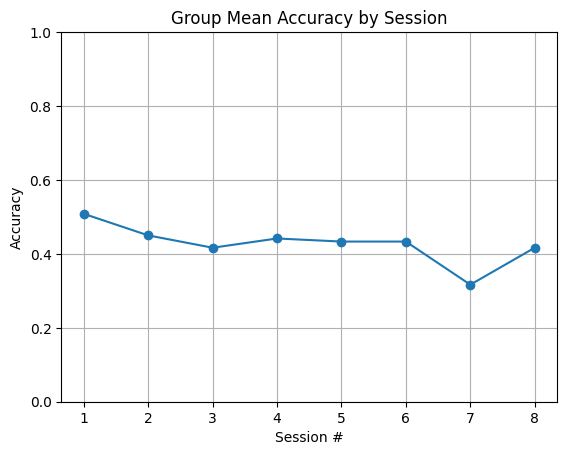

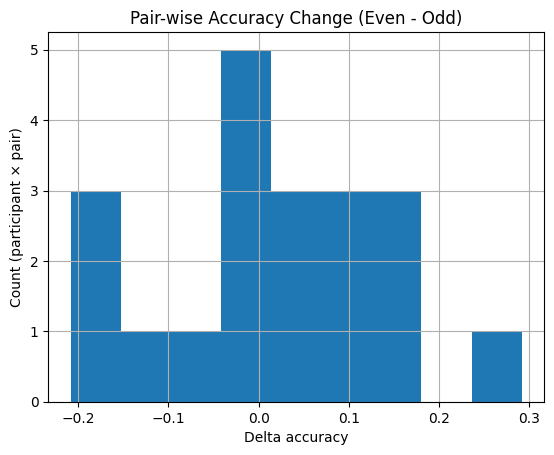

In [13]:
# Group mean accuracy by session
group = (df.groupby("session_no")["correct"].mean().reset_index())
plt.figure()
plt.plot(group["session_no"], group["correct"], marker='o')
plt.title("Group Mean Accuracy by Session")
plt.xlabel("Session #")
plt.ylabel("Accuracy")
plt.xticks(range(1,9))
plt.ylim(0,1)
plt.grid(True)
plt.show()

# Histogram of pair deltas
plt.figure()
plt.hist(pair_delta["delta_even_minus_odd"], bins=9)
plt.title("Pair-wise Accuracy Change (Even - Odd)")
plt.xlabel("Delta accuracy")
plt.ylabel("Count (participant × pair)")
plt.grid(True)
plt.show()